In [1]:
import pandas as pd

In [2]:
!gdown 1F1oYeeovU705q5XWVQRgnxSi41YE23_7 # FH
!gdown 1EMeMw9-dLcbOygYy2uww-w1qg6ooMjru # IDA
!gdown 1B2Sg2mcNLVQD3X_5FmWzcAWrzzAk4cCz # GOB

Downloading...
From: https://drive.google.com/uc?id=1F1oYeeovU705q5XWVQRgnxSi41YE23_7
To: /content/fh_minmax_normalized_missing_vals_final.xlsx
100% 16.3k/16.3k [00:00<00:00, 29.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1EMeMw9-dLcbOygYy2uww-w1qg6ooMjru
To: /content/ida_minmax_normalized_missing_vals.xlsx
100% 17.1k/17.1k [00:00<00:00, 30.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1B2Sg2mcNLVQD3X_5FmWzcAWrzzAk4cCz
To: /content/gob_minmax_normalized_missing_vals.xlsx
100% 13.3k/13.3k [00:00<00:00, 807kB/s]


In [3]:
fh_raw = pd.read_excel("fh_minmax_normalized_missing_vals_final.xlsx").set_index("country").drop(columns=["total_pop", "pib_percapita"])
ida_raw = pd.read_excel("ida_minmax_normalized_missing_vals.xlsx").set_index("country").drop(columns=["total_pop", "pib_percapita"])
gob_raw = pd.read_excel("gob_minmax_normalized_missing_vals.xlsx").set_index("country")

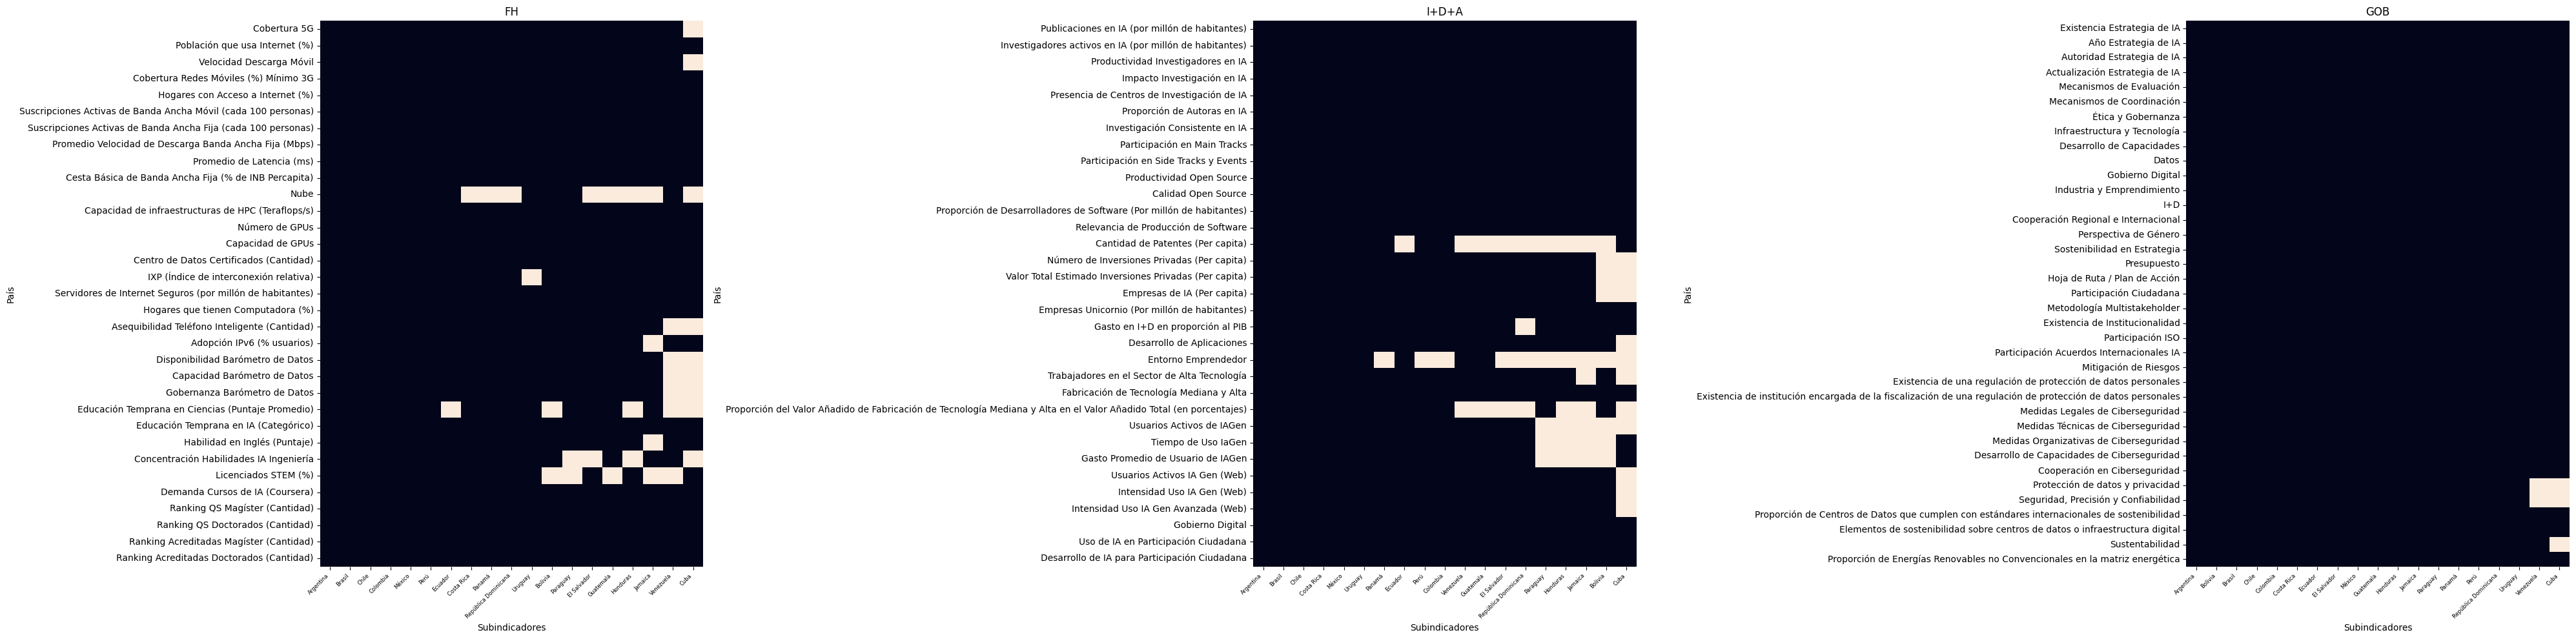

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Suppose your dataframes are df1, df2, df3
dfs = [fh_raw, ida_raw, gob_raw]
dfs_sorted = [df.loc[df.isna().sum(axis=1).sort_values(ascending=True).index] for df in dfs]
titles = ["FH", "I+D+A", "GOB"]

plt.figure(figsize=(40, 10))

for i, (df, title) in enumerate(zip(dfs_sorted, titles), start=1):
    plt.subplot(1, 3, i)
    sns.heatmap(df.isna().T, cbar=False)
    plt.title(title)
    plt.xlabel("Subindicadores")
    plt.ylabel("País")

    plt.xticks(rotation=45, ha="right", fontsize=6)

plt.tight_layout()
plt.show()

/tmp/ipython-input-1949311075.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s1 = (fh_raw.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(fh_raw.columns))*100)).sort_values(ascending=False)
/tmp/ipython-input-1949311075.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s2 = (ida_raw.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(ida_raw.columns))*100)).sort_values(ascending=False)
/tmp/ipython-input-1949311075.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a futu

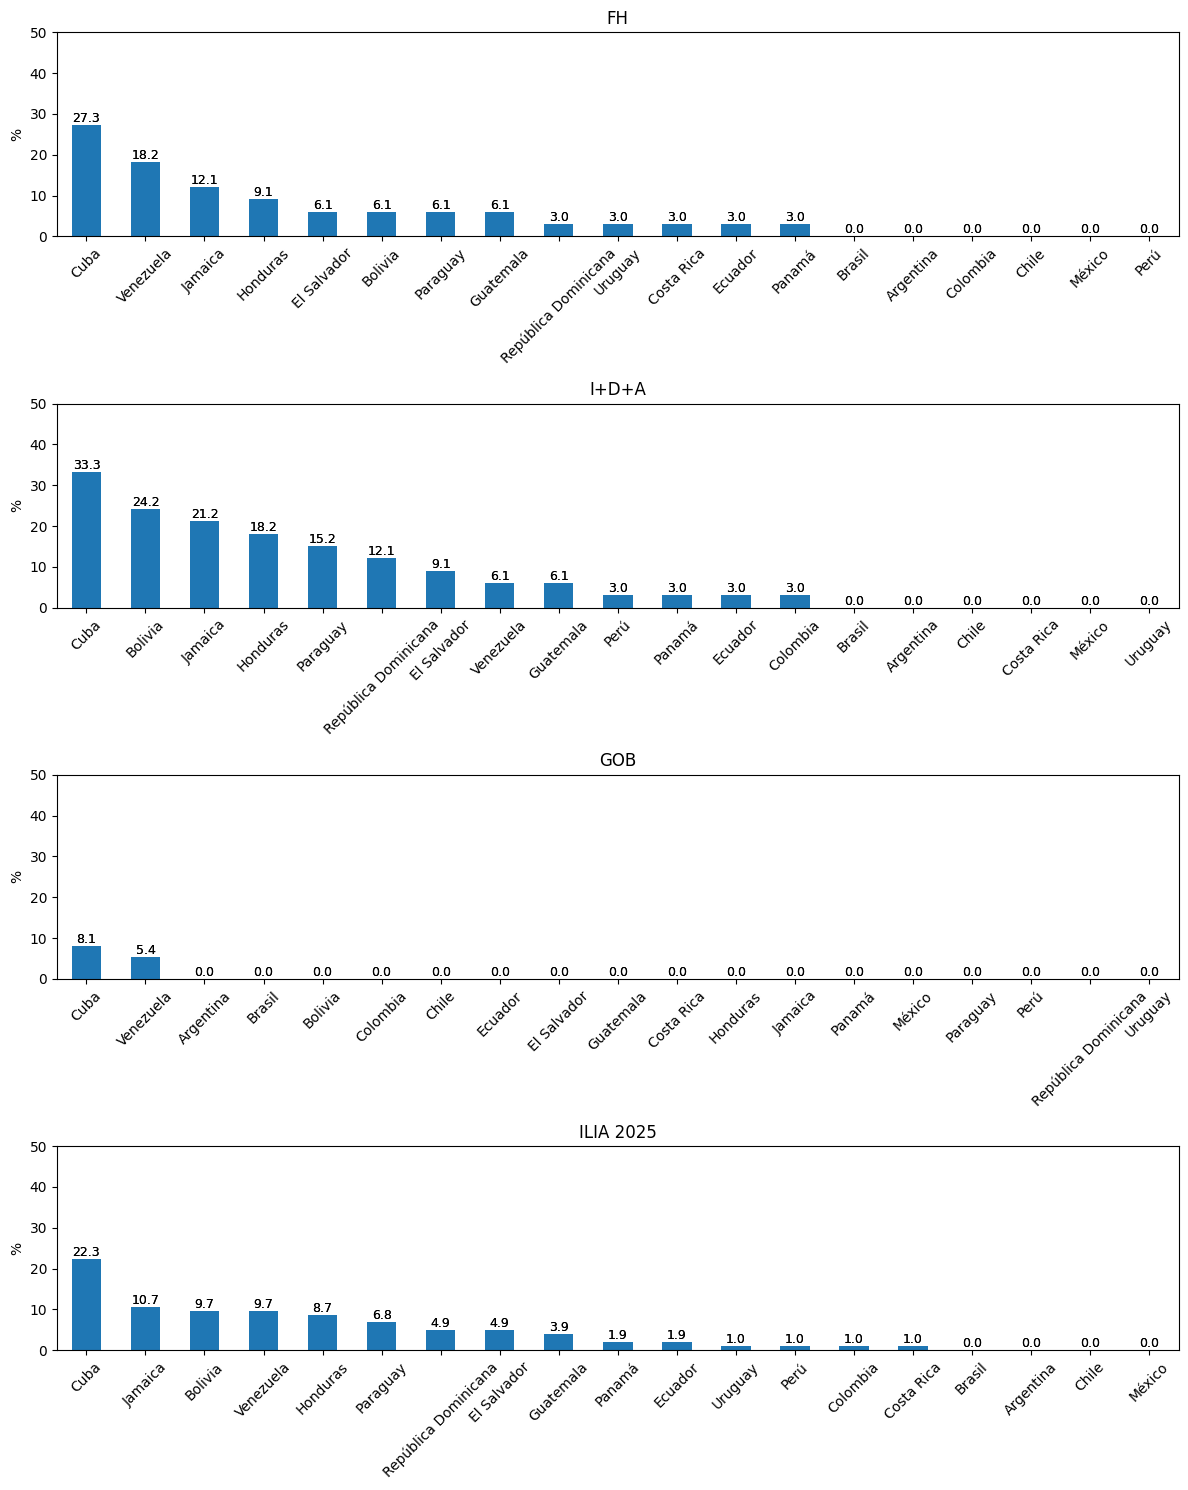

In [ ]:
import numpy as np

# Placeholder data (replace these with your own series)
s1 = (fh_raw.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(fh_raw.columns))*100)).sort_values(ascending=False)
s2 = (ida_raw.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(ida_raw.columns))*100)).sort_values(ascending=False)
s3 = (gob_raw.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(gob_raw.columns))*100)).sort_values(ascending=False)

ilia = pd.concat([fh_raw, ida_raw, gob_raw], axis=1)
s4 = (ilia.isna().replace({True: 1, False: 0}).sum(axis=1)*((1/len(ilia.columns))*100)).sort_values(ascending=False)

series_list = [s1, s2, s3, s4]

plt.figure(figsize=(12, 15))

names = ["FH", "I+D+A", "GOB", "ILIA 2025"]

for i, (s, title) in enumerate(zip(series_list, names), start=1):
    plt.subplot(4, 1, i)
    ax = s.plot(kind='bar')
    s.plot(kind='bar')  # separate plot for each series
    plt.title(title)
    plt.ylabel("%")
    plt.xlabel("")
    plt.ylim([0,50])
    plt.xticks(rotation=45)

    # Add value labels on top of bars
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            height,
            f"{height:.1f}",           # format number
            ha="center", va="bottom",  # align text
            fontsize=9
        )

plt.tight_layout()
plt.show()




***Imputación Naive***

# ILIA 2025

In [ ]:
!gdown 1vit96nEgN7Xh0S2dEYGY728WJyEHOSD4f9bYwlSVR7s
!gdown 1Hlq78_MreVFXoJFhydiO0YlN2MCHzW0IjjzzvazccdY
!gdown 1nGJpvHvc-n-AD-EXqKIXyaqnGf-SAM8uwYpdkaksSqI

Downloading...
From (original): https://drive.google.com/uc?id=1vit96nEgN7Xh0S2dEYGY728WJyEHOSD4f9bYwlSVR7s
From (redirected): https://docs.google.com/spreadsheets/d/1vit96nEgN7Xh0S2dEYGY728WJyEHOSD4f9bYwlSVR7s/export?format=xlsx
To: /content/VALORES IMPUTADOS FH.xlsx
45.5kB [00:00, 77.8MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1Hlq78_MreVFXoJFhydiO0YlN2MCHzW0IjjzzvazccdY
From (redirected): https://docs.google.com/spreadsheets/d/1Hlq78_MreVFXoJFhydiO0YlN2MCHzW0IjjzzvazccdY/export?format=xlsx
To: /content/VALORES IMPUTADOS I+D+A.xlsx
71.3kB [00:00, 76.6MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1nGJpvHvc-n-AD-EXqKIXyaqnGf-SAM8uwYpdkaksSqI
From (redirected): https://docs.google.com/spreadsheets/d/1nGJpvHvc-n-AD-EXqKIXyaqnGf-SAM8uwYpdkaksSqI/export?format=xlsx
To: /content/VALORES IMPUTADOS GOB.xlsx
89.0kB [00:00, 16.9MB/s]


In [ ]:
rename = {"Bolivia": "Bolivia (Estado Plurinacional de)", "Venezuela": "Venezuela (República Bolivariana de)"}

## FH Final

In [ ]:
subindicators_names = [
    'Cobertura 5G (%)',
    'Población que usa Internet (%)',
    'Velocidad Descarga Móvil',
    'Cobertura Redes Móviles (%) Mínimo 3G',
    'Hogares con Acceso a Internet (%)',
    'Suscripciones Activas de Banda Ancha Móvil (cada 100 personas)',
    'Suscripciones Activas de Banda Ancha Fija (cada 100 personas)',
    'Promedio Velocidad de Descarga Banda Ancha Fija (Mbps)',
    'Promedio de Latencia (ms)',
    'Cesta Básica de Banda Ancha Fija (% de INB Percapita)',
    'Nube',
    'Capacidad de infraestructuras de HPC (Teraflops/s)',
    'Número de GPUs',
    'Capacidad de GPUs',
    'Centro de Datos Certificados (Cantidad)',
    'IXP (Índice de interconexión relativa)',
    'Servidores de Internet Seguros (por millón de habitantes)',
    'Hogares que tienen Computadora (%)',
    'Asequibilidad Teléfono Inteligente (Cantidad)',
    'Adopción IPv6 (% usuarios)', 'Disponibilidad Barómetro de Datos',
    'Capacidad Barómetro de Datos', 'Gobernanza Barómetro de Datos',
    'Educación Temprana en Ciencias (Puntaje Promedio)',
    'Educación Temprana en IA (Categórico)',
    'Habilidad en Inglés (Puntaje)', # RESTAURADO
    'Concentración Habilidades IA Ingeniería', 'Licenciados STEM (%)',
    "Demanda Cursos de IA (Coursera)",
    'Ranking QS Magíster (Cantidad)', 'Ranking QS Doctorados (Cantidad)',
    'Ranking Acreditadas Magíster (Cantidad)',
    'Ranking Acreditadas Doctorados (Cantidad)'
        ]

imputed = pd.read_excel("VALORES IMPUTADOS FH.xlsx", sheet_name="imputados").drop(columns=["total_pop", "pib_percapita"]).replace({"country": rename}).set_index("country").rename(columns={"Velocidad Descarga Móvil (Puntaje)": "Velocidad Descarga Móvil"})
fh_matrix = imputed[subindicators_names]

fh_indicators = {
    "Conectividad": [
        'Cobertura 5G (%)',
        'Población que usa Internet (%)',
        'Velocidad Descarga Móvil',
        'Cobertura Redes Móviles (%) Mínimo 3G',
        'Hogares con Acceso a Internet (%)',
        'Suscripciones Activas de Banda Ancha Móvil (cada 100 personas)',
        'Suscripciones Activas de Banda Ancha Fija (cada 100 personas)',
        'Promedio Velocidad de Descarga Banda Ancha Fija (Mbps)',
        'Promedio de Latencia (ms)',
        'Cesta Básica de Banda Ancha Fija (% de INB Percapita)'
        ],
    "Cómputo": [
        'Nube',
       'Capacidad de infraestructuras de HPC (Teraflops/s)',
        'Número de GPUs',
        'Capacidad de GPUs',
       'Centro de Datos Certificados (Cantidad)', 'IXP (Índice de interconexión relativa)',
       'Servidores de Internet Seguros (por millón de habitantes)'],
    "Dispositivos": ['Hogares que tienen Computadora (%)',
       'Asequibilidad Teléfono Inteligente (Cantidad)',
       'Adopción IPv6 (% usuarios)'],
    "Barómetro de Datos": [
        'Disponibilidad Barómetro de Datos',
       'Capacidad Barómetro de Datos',
        'Gobernanza Barómetro de Datos'],
    "Alfabetización en IA": ['Educación Temprana en Ciencias (Puntaje Promedio)',
       'Educación Temprana en IA (Categórico)',
       'Habilidad en Inglés (Puntaje)'
       ],
    "Formación Profesional en IA": [
        'Concentración Habilidades IA Ingeniería',
        'Licenciados STEM (%)',
        "Demanda Cursos de IA (Coursera)"],
    "Talento Humano Avanzado": ['Ranking QS Magíster (Cantidad)', 'Ranking QS Doctorados (Cantidad)',
       'Ranking Acreditadas Magíster (Cantidad)',
       'Ranking Acreditadas Doctorados (Cantidad)']
}

fh_subdimensions = {
    "Infraestructura": ["Conectividad", "Cómputo", "Dispositivos"],
    "Datos": ["Barómetro de Datos"],
    "Talento Humano": ["Alfabetización en IA", "Formación Profesional en IA", "Talento Humano Avanzado"]
}

fh_indicator_ponderation = {
    "Conectividad": 0.5,
    "Cómputo": 0.25,
    "Dispositivos": 0.25,
    "Barómetro de Datos": 1,
    "Alfabetización en IA": 0.4,
    "Formación Profesional en IA": 0.3,
    "Talento Humano Avanzado": 0.3
}

fh_subdimensions_ponderation = {
    "Infraestructura": 0.45,
    "Datos": 0.25,
    "Talento Humano": 0.3
}

indicators_df = []

connectiviy =  fh_matrix[fh_indicators["Conectividad"]].mean(axis=1).rename("Conectividad")
computing =  fh_matrix[fh_indicators["Cómputo"]].mean(axis=1).rename("Cómputo")
devices =  fh_matrix[fh_indicators["Dispositivos"]].mean(axis=1).rename("Dispositivos")

indicators_df.append(pd.concat([connectiviy, computing, devices], axis=1))


connectiviy_avg =  (fh_matrix[fh_indicators["Conectividad"]].mean(axis=1)*fh_indicator_ponderation["Conectividad"]).rename("Conectividad")
computing_avg =  (fh_matrix[fh_indicators["Cómputo"]].mean(axis=1)*fh_indicator_ponderation["Cómputo"]).rename("Cómputo")
devices_avg =  (fh_matrix[fh_indicators["Dispositivos"]].mean(axis=1)*fh_indicator_ponderation["Dispositivos"]).rename("Dispositivos")

infrastructure_subd = pd.concat([connectiviy_avg, computing_avg, devices_avg], axis=1)
infrastructure_pond = infrastructure_subd.sum(axis=1).rename("Promedio Infraestructura")

####################

barometer =  fh_matrix[fh_indicators["Barómetro de Datos"]].mean(axis=1).rename("Barómetro de Datos")
indicators_df.append(pd.concat([barometer], axis=1))

barometer_avg =  (fh_matrix[fh_indicators["Barómetro de Datos"]].mean(axis=1)*fh_indicator_ponderation["Barómetro de Datos"]).rename("Barómetro de Datos")
data_subd = pd.concat([barometer_avg], axis=1)

data_subd = data_subd.sum(axis=1).rename("Promedio Datos")

###################

literacy =  fh_matrix[fh_indicators["Alfabetización en IA"]].mean(axis=1).rename("Alfabetización en IA")
skills =  fh_matrix[fh_indicators["Formación Profesional en IA"]].mean(axis=1).rename("Formación Profesional en IA")
advanced_talent =  fh_matrix[fh_indicators["Talento Humano Avanzado"]].mean(axis=1).rename("Talento Humano Avanzado")

indicators_df.append(pd.concat([literacy, skills, advanced_talent], axis=1))

literacy_avg =  (fh_matrix[fh_indicators["Alfabetización en IA"]].mean(axis=1)*fh_indicator_ponderation["Alfabetización en IA"]).rename("Alfabetización en IA")
skills_avg =  (fh_matrix[fh_indicators["Formación Profesional en IA"]].mean(axis=1)*fh_indicator_ponderation["Formación Profesional en IA"]).rename("Formación Profesional en IA")
advanced_talent_avg =  (fh_matrix[fh_indicators["Talento Humano Avanzado"]].mean(axis=1)*fh_indicator_ponderation["Talento Humano Avanzado"]).rename("Talento Humano Avanzado")

talent_subd = pd.concat([literacy_avg, skills_avg, advanced_talent_avg], axis=1)
talent_pond = talent_subd.sum(axis=1).rename("Promedio Talento Humano")


######## VALORES CRUDOS
raw_fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
raw_fh["Puntaje Factores Habilitantes"] = raw_fh.sum(axis=1)

### Ponderación subdimensión
infrastructure_pond = infrastructure_pond*fh_subdimensions_ponderation["Infraestructura"]
data_subd = data_subd*fh_subdimensions_ponderation["Datos"]
talent_pond = talent_pond*fh_subdimensions_ponderation["Talento Humano"]

FH_DIMENSION_PONDERATOR = 0.4

fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
fh["Puntaje Factores Habilitantes"] = fh.sum(axis=1)*FH_DIMENSION_PONDERATOR
fh["Puntaje Factores Habilitantes (Bruto)"] = fh[["Promedio Infraestructura", "Promedio Datos", "Promedio Talento Humano"]].sum(axis=1)
fh



,Promedio Infraestructura,Promedio Datos,Promedio Talento Humano,Puntaje Factores Habilitantes,Puntaje Factores Habilitantes (Bruto)
country,,,,,
Argentina,23.477366,14.641905,12.176221,20.118197,50.295492
Bolivia (Estado Plurinacional de),16.743463,6.961417,8.526291,12.892468,32.231171
Brasil,32.143112,16.245798,10.195107,23.433607,58.584017
Chile,28.714609,16.443345,20.024866,26.073128,65.182820
Colombia,20.713882,14.987869,13.885823,19.835030,49.587574
Costa Rica,23.898788,9.932262,16.085970,19.966808,49.917020
Cuba,6.958083,4.026511,7.953584,7.575271,18.938178
Ecuador,18.478161,14.717691,10.651335,17.538874,43.847186
El Salvador,17.185655,6.447786,8.741553,12.949998,32.374994


In [ ]:
subindicators_names = [
    'Cobertura 5G (%)',
    'Población que usa Internet (%)',
    'Velocidad Descarga Móvil',
    'Cobertura Redes Móviles (%) Mínimo 3G',
    'Hogares con Acceso a Internet (%)',
    'Suscripciones Activas de Banda Ancha Móvil (cada 100 personas)',
    'Suscripciones Activas de Banda Ancha Fija (cada 100 personas)',
    'Promedio Velocidad de Descarga Banda Ancha Fija (Mbps)',
    'Promedio de Latencia (ms)',
    'Cesta Básica de Banda Ancha Fija (% de INB Percapita)',
    'Nube',
    'Capacidad de infraestructuras de HPC (Teraflops/s)',
    'Número de GPUs',
    'Capacidad de GPUs',
    'Centro de Datos Certificados (Cantidad)',
    'IXP (Índice de interconexión relativa)',
    'Servidores de Internet Seguros (por millón de habitantes)',
    'Hogares que tienen Computadora (%)',
    'Asequibilidad Teléfono Inteligente (Cantidad)',
    'Adopción IPv6 (% usuarios)', 'Disponibilidad Barómetro de Datos',
    'Capacidad Barómetro de Datos', 'Gobernanza Barómetro de Datos',
    'Educación Temprana en Ciencias (Puntaje Promedio)',
    'Educación Temprana en IA (Categórico)',
    'Habilidad en Inglés (Puntaje)', # RESTAURADO
    'Concentración Habilidades IA Ingeniería', 'Licenciados STEM (%)',
    "Demanda Cursos de IA (Coursera)",
    'Ranking QS Magíster (Cantidad)', 'Ranking QS Doctorados (Cantidad)',
    'Ranking Acreditadas Magíster (Cantidad)',
    'Ranking Acreditadas Doctorados (Cantidad)'
        ]



## I+D+A Final

In [ ]:
ida_matrix = pd.read_excel("VALORES IMPUTADOS I+D+A.xlsx", sheet_name="imputados").drop(columns=["total_pop", "pib_percapita"]).replace({"country": rename}).set_index("country")

In [ ]:
ida_indicators = {
    "Investigación": [
        'Publicaciones en IA (por millón de habitantes)',
        'Investigadores activos en IA (por millón de habitantes)',
        'Productividad Investigadores en IA',
        'Impacto Investigación en IA',
        'Presencia de Centros de Investigación de IA',
        'Proporción de Autoras en IA',
        'Investigación Consistente en IA',
        'Participación en Main Tracks',
        'Participación en Side Tracks y Events'
        ],
    "Desarrollo": [
        'Productividad Open Source',
       'Calidad Open Source',
       'Cantidad de Patentes (Per capita)',
        'Proporción de Desarrolladores de Software (Por millón de habitantes)',
        'Relevancia de Producción de Software',
        ],
    "Innovación": [
        'Número de Inversiones Privadas (Per capita)',
       'Valor Total Estimado Inversiones Privadas (Per capita)',
       'Empresas de IA (Per capita)',
       'Empresas Unicornio (Por millón de habitantes)',
        'Gasto en I+D en proporción al PIB',
        'Desarrollo de Aplicaciones',
        'Entorno Emprendedor'],
    "Industria": [
        'Trabajadores en el Sector de Alta Tecnología',
       'Fabricación de Tecnología Mediana y Alta',
        'Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes)',
        ],
    "IA Generativa": [
        'Usuarios Activos de IAGen',
        'Tiempo de Uso IaGen',
        'Gasto Promedio de Usuario de IAGen',
        'Usuarios Activos IA Gen (Web)'
    ],
    "IA Web": [
        'Intensidad Uso IA Gen (Web)',
        'Intensidad Uso IA Gen Avanzada (Web)'
    ],
    "Gobierno": [
        'Gobierno Digital',
        'Uso de IA en Participación Ciudadana',
        'Desarrollo de IA para Participación Ciudadana'
       ]
}

ida_subdimensions = {
    "Investigación": ["Investigación"],
    "I+D": ["Innovación", "Desarrollo"],
    "Adopción": ["Industria", "Gobierno", "IA Generativa", "IA Web"]
}

ida_indicator_ponderation = {
    "Investigación": 1.0,
    "Innovación": 0.5,
    "Desarrollo": 0.5,
    "Industria": 1/4,
    "Gobierno": 1/4,
    "IA Generativa": 1/4,
    "IA Web": 1/4
}

ida_subdimensions_ponderation = {
    "Investigación": 0.4,
    "I+D": 0.3,
    "Adopción": 0.3
}

indicators_df = []

investigation =  ida_matrix[ida_indicators["Investigación"]].mean(axis=1).rename("Investigación")

indicators_df.append(pd.concat([investigation], axis=1))

investigation_avg =  (ida_matrix[ida_indicators["Investigación"]].mean(axis=1)*ida_indicator_ponderation["Investigación"]).rename("Investigación")

investigation_subd = pd.concat([investigation_avg], axis=1)
investigation_pond = investigation_subd.sum(axis=1).rename("Promedio Investigación")

####################

innovation =  ida_matrix[ida_indicators["Innovación"]].mean(axis=1).rename("Innovación")
development =  ida_matrix[ida_indicators["Desarrollo"]].mean(axis=1).rename("Desarrollo")
indicators_df.append(pd.concat([innovation, development], axis=1))

innovation_avg =  (ida_matrix[ida_indicators["Innovación"]].mean(axis=1)*ida_indicator_ponderation["Innovación"]).rename("Innovación")
development_avg =  (ida_matrix[ida_indicators["Desarrollo"]].mean(axis=1)*ida_indicator_ponderation["Desarrollo"]).rename("Desarrollo")

iplusd_subd = pd.concat([innovation_avg, development_avg], axis=1)
iplusd_pond = iplusd_subd.sum(axis=1).rename("Promedio I+D")

###################

industry =  ida_matrix[ida_indicators["Industria"]].mean(axis=1).rename("Industria")
government =  ida_matrix[ida_indicators["Gobierno"]].mean(axis=1).rename("Gobierno")
generative_ai = ida_matrix[ida_indicators["IA Generativa"]].mean(axis=1).rename("IA Generativa")
web_ai = ida_matrix[ida_indicators["IA Web"]].mean(axis=1).rename("IA Web")

indicators_df.append(pd.concat([industry, government, generative_ai, web_ai], axis=1))

industry_avg =  (ida_matrix[ida_indicators["Industria"]].mean(axis=1)*ida_indicator_ponderation["Industria"]).rename("Industria")
government_avg =  (ida_matrix[ida_indicators["Gobierno"]].mean(axis=1)*ida_indicator_ponderation["Gobierno"]).rename("Gobierno")
generative_ai_avg =  (ida_matrix[ida_indicators["IA Generativa"]].mean(axis=1)*ida_indicator_ponderation["IA Generativa"]).rename("IA Generativa")
web_ai_avg =  (ida_matrix[ida_indicators["IA Web"]].mean(axis=1)*ida_indicator_ponderation["IA Web"]).rename("IA Web")

adoption_subd = pd.concat([industry_avg, government_avg, generative_ai_avg, web_ai_avg], axis=1)
adoption_pond = adoption_subd.sum(axis=1).rename("Promedio Adopción")

######## VALORES CRUDOS
raw_ida = pd.concat([investigation_pond, iplusd_pond, adoption_pond], axis=1)
raw_ida["Puntaje I+D+A"] = raw_ida.sum(axis=1)

### Ponderación subdimensión
investigation_pond = investigation_pond*ida_subdimensions_ponderation["Investigación"]
iplusd_pond = iplusd_pond*ida_subdimensions_ponderation["I+D"]
adoption_pond = adoption_pond*ida_subdimensions_ponderation["Adopción"]

IDA_DIMENSION_PONDERATOR = 0.35

ida = pd.concat([investigation_pond, iplusd_pond, adoption_pond], axis=1)
ida["Puntaje I+D+A"] = ida.sum(axis=1)*IDA_DIMENSION_PONDERATOR
ida["Puntaje I+D+A (Bruto)"] = ida[["Promedio Investigación",	"Promedio I+D", "Promedio Adopción"]].sum(axis=1)
ida



,Promedio Investigación,Promedio I+D,Promedio Adopción,Puntaje I+D+A,Puntaje I+D+A (Bruto)
country,,,,,
Argentina,17.208989,14.133977,14.870471,16.174703,46.213436
Bolivia (Estado Plurinacional de),7.112744,7.635514,12.450693,9.519633,27.198952
Brasil,22.554449,15.358015,21.345187,20.740178,59.257650
Chile,32.871316,15.045460,19.736792,23.678749,67.653567
Colombia,18.515096,9.880159,20.185871,17.003394,48.581126
Costa Rica,13.522438,7.942181,19.879677,14.470503,41.344295
Cuba,13.671627,10.987788,7.024487,11.089366,31.683903
Ecuador,16.336121,8.423366,16.408337,14.408738,41.167824
El Salvador,6.475882,8.395603,12.177229,9.467050,27.048715


## GOB Final

In [ ]:
gob_matrix = pd.read_excel("VALORES IMPUTADOS GOB.xlsx", sheet_name="imputados").replace({"country": rename}).set_index("country")

In [ ]:
gob_indicators = {
    "Estrategia de IA": [
        'Existencia Estrategia de IA', 'Año Estrategia de IA',
       'Autoridad Estrategia de IA', 'Actualización Estrategia de IA',
       'Mecanismos de Evaluación', 'Mecanismos de Coordinación',
       'Ética y Gobernanza', 'Infraestructura y Tecnología',
       'Desarrollo de Capacidades', 'Datos', 'Gobierno Digital',
       'Industria y Emprendimiento', 'I+D',
       'Cooperación Regional e Internacional', 'Perspectiva de Género',
       'Sostenibilidad en Estrategia', 'Presupuesto',
       'Hoja de Ruta / Plan de Acción'
        ],
    "Involucramiento de la sociedad": ['Participación Ciudadana',
       'Metodología Multistakeholder'
       ],
    "Institucionalidad": ['Existencia de Institucionalidad'],
    "Participación en definición de Estándares": ['Participación ISO'],
    "Participación en organismos internacionales": ['Participación Acuerdos Internacionales IA',],
    "Regulación sobre IA": ['Mitigación de Riesgos'],
    "Regulación de datos personales": [
        'Existencia de una regulación de protección de datos personales',
        'Existencia de institución encargada de la fiscalización de una regulación de protección de datos personales'
    ],
    "Ciberseguridad": ['Medidas Legales de Ciberseguridad',
       'Medidas Técnicas de Ciberseguridad',
       'Medidas Organizativas de Ciberseguridad',
       'Desarrollo de Capacidades de Ciberseguridad',
       'Cooperación en Ciberseguridad'],
    "Ética y Sustentabilidad": ['Protección de datos y privacidad',
       'Seguridad, Precisión y Confiabilidad',
       'Proporción de Centros de Datos que cumplen con estándares internacionales de sostenibilidad',
       'Elementos de sostenibilidad sobre centros de datos o infraestructura digital',
       'Sustentabilidad',
       'Proporción de Energías Renovables no Convencionales en la matriz energética']
}

gob_subdimensions = {
    "Visión e Institucionalidad": ["Estrategia de IA", "Involucramiento de la sociedad", "Institucionalidad"],
    "Internacional": ["Participación en definición de Estándares", "Participación en organismos internacionales"],
    "Regulación": ["Regulación sobre IA", "Ciberseguridad", "Ética y Sustentabilidad"]
}

gob_indicator_ponderation = {
    "Estrategia de IA": 0.5,
    "Involucramiento de la sociedad": 0.25,
    "Institucionalidad": 0.25,
    "Participación en definición de Estándares": 0.5,
    "Participación en organismos internacionales": 0.5,
    "Regulación sobre IA": 0.1,
    "Regulación de datos personales": 0.2,
    "Ciberseguridad": 0.2,
    "Ética y Sustentabilidad": 0.5
}

gob_subdimensions_ponderation = {
    "Visión e Institucionalidad": 0.5,
    "Internacional": 0.2,
    "Regulación": 0.3
}

indicators_df = []

ia_strategy =  gob_matrix[gob_indicators["Estrategia de IA"]].mean(axis=1).rename("Estrategia de IA")
society =  gob_matrix[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1).rename("Involucramiento de la sociedad")
institutionality =  gob_matrix[gob_indicators["Institucionalidad"]].mean(axis=1).rename("Institucionalidad")

indicators_df.append(pd.concat([ia_strategy, society, institutionality], axis=1))

ia_strategy_avg =  (gob_matrix[gob_indicators["Estrategia de IA"]].mean(axis=1)*gob_indicator_ponderation["Estrategia de IA"]).rename("Estrategia de IA")
society_avg =  (gob_matrix[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1)*gob_indicator_ponderation["Involucramiento de la sociedad"]).rename("Involucramiento de la sociedad")
institutionality_avg =  (gob_matrix[gob_indicators["Institucionalidad"]].mean(axis=1)*gob_indicator_ponderation["Institucionalidad"]).rename("Institucionalidad")

vision_inst_subd = pd.concat([ia_strategy_avg, society_avg, institutionality_avg], axis=1)
vision_inst_pond = vision_inst_subd.sum(axis=1).rename("Promedio Visión e Institucionalidad")

####################

standards =  gob_matrix[gob_indicators["Participación en definición de Estándares"]].mean(axis=1).rename("Participación en definición de Estándares")
international_orgs =  gob_matrix[gob_indicators["Participación en organismos internacionales"]].mean(axis=1).rename("Participación en organismos internacionales")

indicators_df.append(pd.concat([standards, international_orgs], axis=1))

standards_avg =  (gob_matrix[gob_indicators["Participación en definición de Estándares"]].mean(axis=1)*gob_indicator_ponderation["Participación en definición de Estándares"]).rename("Participación en definición de Estándares")
international_orgs_avg =  (gob_matrix[gob_indicators["Participación en organismos internacionales"]].mean(axis=1)*gob_indicator_ponderation["Participación en organismos internacionales"]).rename("Participación en organismos internacionales")

international_subd = pd.concat([standards_avg, international_orgs_avg], axis=1)

international_subd = international_subd.sum(axis=1).rename("Promedio Internacional")

###################

ia_regulation =  gob_matrix[gob_indicators["Regulación sobre IA"]].mean(axis=1).rename("Regulación sobre IA")
data_regulation =  gob_matrix[gob_indicators["Regulación de datos personales"]].mean(axis=1).rename("Regulación de datos personales")
cibersecurity =  gob_matrix[gob_indicators["Ciberseguridad"]].mean(axis=1).rename("Ciberseguridad")
ethics =  gob_matrix[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1).rename("Ética y Sustentabilidad")

indicators_df.append(pd.concat([ia_regulation, data_regulation, cibersecurity, ethics], axis=1))

ia_regulation_avg =  (gob_matrix[gob_indicators["Regulación sobre IA"]].mean(axis=1)*gob_indicator_ponderation["Regulación sobre IA"]).rename("Regulación sobre IA")
data_regulation_avg =  (gob_matrix[gob_indicators["Regulación de datos personales"]].mean(axis=1)*gob_indicator_ponderation["Regulación de datos personales"]).rename("Regulación de datos personales")
cibersecurity_avg =  (gob_matrix[gob_indicators["Ciberseguridad"]].mean(axis=1)*gob_indicator_ponderation["Ciberseguridad"]).rename("Ciberseguridad")
ethics_avg =  (gob_matrix[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1)*gob_indicator_ponderation["Ética y Sustentabilidad"]).rename("Ética y Sustentabilidad")

regulation_subd = pd.concat([ia_regulation_avg, data_regulation_avg, cibersecurity_avg, ethics_avg], axis=1)
regulation_pond = regulation_subd.sum(axis=1).rename("Promedio Regulación")

######## VALORES CRUDOS
raw_gob = pd.concat([vision_inst_pond, international_subd, regulation_pond], axis=1)
raw_gob["Puntaje Gobernanza"] = raw_gob.sum(axis=1)

### Ponderación subdimensión
vision_inst_pond = vision_inst_pond*gob_subdimensions_ponderation["Visión e Institucionalidad"]
international_subd = international_subd*gob_subdimensions_ponderation["Internacional"]
regulation_pond = regulation_pond*gob_subdimensions_ponderation["Regulación"]

gob_DIMENSION_PONDERATOR = 0.25

gob = pd.concat([vision_inst_pond, international_subd, regulation_pond], axis=1)
gob["Puntaje Gobernanza"] = gob.sum(axis=1)*gob_DIMENSION_PONDERATOR
gob["Puntaje Gobernanza (Bruto)"] = gob[["Promedio Visión e Institucionalidad", "Promedio Internacional", "Promedio Regulación"]].sum(axis=1)
gob

,Promedio Visión e Institucionalidad,Promedio Internacional,Promedio Regulación,Puntaje Gobernanza,Puntaje Gobernanza (Bruto)
country,,,,,
Argentina,34.953704,15.0,16.790045,16.685937,66.743749
Bolivia (Estado Plurinacional de),0.000000,7.5,7.085510,3.646378,14.585510
Brasil,48.148148,20.0,24.736387,23.221134,92.884535
Chile,47.222222,12.5,23.515996,20.809555,83.238218
Colombia,37.384259,17.5,21.129735,19.003498,76.013994
Costa Rica,43.634259,15.0,18.920688,19.388737,77.554948
Cuba,23.842593,5.0,11.246441,10.022258,40.089034
Ecuador,0.000000,15.0,19.928813,8.732203,34.928813
El Salvador,9.375000,12.5,16.613923,9.622231,38.488923


## Total ILIA 2025

In [ ]:
# fh, ida, gob
fh_score = fh["Puntaje Factores Habilitantes"]
ida_score = ida["Puntaje I+D+A"]
gob_score = gob["Puntaje Gobernanza"]
scores_df = pd.concat([fh_score, ida_score, gob_score], axis=1)

final_df = scores_df
final_df["Puntaje ILIA"] = final_df.sum(axis=1)
final_df


,Puntaje Factores Habilitantes,Puntaje I+D+A,Puntaje Gobernanza,Puntaje ILIA
country,,,,
Argentina,20.118197,16.174703,16.685937,52.978837
Bolivia (Estado Plurinacional de),12.892468,9.519633,3.646378,26.058479
Brasil,23.433607,20.740178,23.221134,67.394918
Chile,26.073128,23.678749,20.809555,70.561431
Colombia,19.835030,17.003394,19.003498,55.841922
Costa Rica,19.966808,14.470503,19.388737,53.826048
Cuba,7.575271,11.089366,10.022258,28.686896
Ecuador,17.538874,14.408738,8.732203,40.679816
El Salvador,12.949998,9.467050,9.622231,32.039278


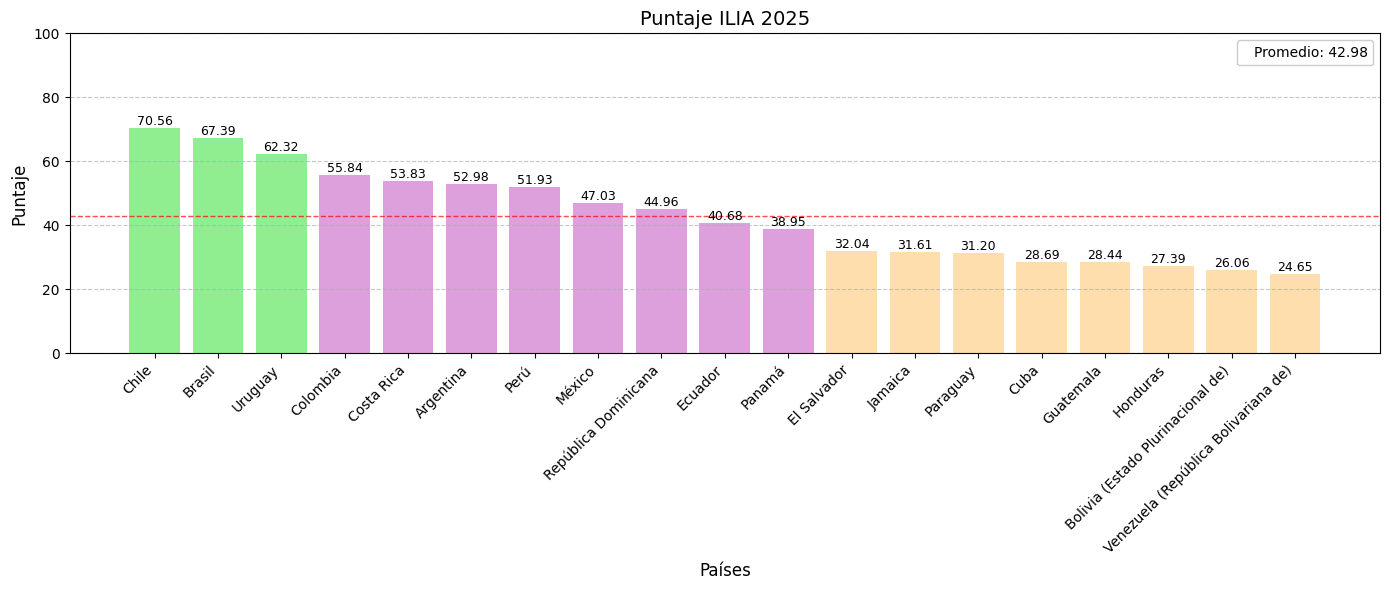

In [ ]:
# Sort the DataFrame by score (descending)
df_sorted = final_df.sort_values("Puntaje ILIA", ascending=False)
average_score = df_sorted['Puntaje ILIA'].mean()

bar_colors = {
    "Chile": "lightgreen",
    "Brasil": "lightgreen",
    "Uruguay": "lightgreen",
    "Colombia": "plum",
    "Costa Rica": "plum",
    "Argentina": "plum",
    "Perú": "plum",
    "México": "plum",
    "República Dominicana": "plum",
    "Ecuador": "plum",
    "Panamá": "plum",
    "El Salvador": "navajowhite",
    "Jamaica": "navajowhite",
    "Paraguay": "navajowhite",
    "Cuba": "navajowhite",
    "Guatemala": "navajowhite",
    "Honduras": "navajowhite",
    "Bolivia (Estado Plurinacional de)": "navajowhite",
    "Venezuela (República Bolivariana de)": "navajowhite"
}

colors = bar_colors.values()

# Create the bar plot
plt.figure(figsize=(14, 6))
bars = plt.bar(df_sorted.index,
               df_sorted['Puntaje ILIA'],
               color=colors,
               label=f'Promedio: {average_score:.2f}')

# Customize the plot
plt.title('Puntaje ILIA 2025', fontsize=14)
plt.ylabel('Puntaje', fontsize=12)
plt.xlabel('Países', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # This sets the y-axis range from 0 to 100

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=9)

# Add a horizontal line for the average
plt.axhline(y=average_score, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Add legend with average value
plt.legend(loc='upper right', framealpha=1, labelcolor="black", handlelength=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ilia_total2025.png")
plt.show()

# Min y Max Efectivos

In [ ]:
min_fh_raw = fh_raw.fillna(0)
max_fh_raw = fh_raw.fillna(fh_raw.max(), downcast='infer')

min_ida_raw = ida_raw.fillna(0)
max_ida_raw = ida_raw.fillna(ida_raw.max(), downcast='infer')

min_gob_raw = gob_raw.fillna(0)
max_gob_raw = gob_raw.fillna(gob_raw.max(), downcast='infer')

min_max_dimns = {}

/tmp/ipython-input-1677779789.py:2: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  max_fh_raw = fh_raw.fillna(fh_raw.max(), downcast='infer')
/tmp/ipython-input-1677779789.py:5: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  max_ida_raw = ida_raw.fillna(ida_raw.max(), downcast='infer')
/tmp/ipython-input-1677779789.py:8: FutureWarning: The 'downcast' keyword in fillna is deprecated and will be removed in a future version. Use res.infer_objects(copy=False) to infer non-object dtype, or pd.to_numeric with the 'downcast' keyword to downcast numeric results.
  max_gob_raw = gob_raw.fillna(gob_raw.max(), downcas

## min FH

In [ ]:
fh_indicators = {
    "Conectividad": [
        'Cobertura 5G',
        'Población que usa Internet (%)',
        'Velocidad Descarga Móvil',
        'Cobertura Redes Móviles (%) Mínimo 3G',
        'Hogares con Acceso a Internet (%)',
        'Suscripciones Activas de Banda Ancha Móvil (cada 100 personas)',
        'Suscripciones Activas de Banda Ancha Fija (cada 100 personas)',
        'Promedio Velocidad de Descarga Banda Ancha Fija (Mbps)',
        'Promedio de Latencia (ms)',
        'Cesta Básica de Banda Ancha Fija (% de INB Percapita)'
        ],
    "Cómputo": [
        'Nube',
       'Capacidad de infraestructuras de HPC (Teraflops/s)',
        'Número de GPUs',
        'Capacidad de GPUs',
       'Centro de Datos Certificados (Cantidad)', 'IXP (Índice de interconexión relativa)',
       'Servidores de Internet Seguros (por millón de habitantes)'],
    "Dispositivos": ['Hogares que tienen Computadora (%)',
       'Asequibilidad Teléfono Inteligente (Cantidad)',
       'Adopción IPv6 (% usuarios)'],
    "Barómetro de Datos": [
        'Disponibilidad Barómetro de Datos',
       'Capacidad Barómetro de Datos',
        'Gobernanza Barómetro de Datos'],
    "Alfabetización en IA": ['Educación Temprana en Ciencias (Puntaje Promedio)',
       'Educación Temprana en IA (Categórico)',
       'Habilidad en Inglés (Puntaje)'
       ],
    "Formación Profesional en IA": [
        'Concentración Habilidades IA Ingeniería',
        'Licenciados STEM (%)',
        "Demanda Cursos de IA (Coursera)"],
    "Talento Humano Avanzado": ['Ranking QS Magíster (Cantidad)', 'Ranking QS Doctorados (Cantidad)',
       'Ranking Acreditadas Magíster (Cantidad)',
       'Ranking Acreditadas Doctorados (Cantidad)']
}

indicators_df = []

connectiviy =  min_fh_raw[fh_indicators["Conectividad"]].mean(axis=1).rename("Conectividad")
computing =  min_fh_raw[fh_indicators["Cómputo"]].mean(axis=1).rename("Cómputo")
devices =  min_fh_raw[fh_indicators["Dispositivos"]].mean(axis=1).rename("Dispositivos")

indicators_df.append(pd.concat([connectiviy, computing, devices], axis=1))


connectiviy_avg =  (min_fh_raw[fh_indicators["Conectividad"]].mean(axis=1)*fh_indicator_ponderation["Conectividad"]).rename("Conectividad")
computing_avg =  (min_fh_raw[fh_indicators["Cómputo"]].mean(axis=1)*fh_indicator_ponderation["Cómputo"]).rename("Cómputo")
devices_avg =  (min_fh_raw[fh_indicators["Dispositivos"]].mean(axis=1)*fh_indicator_ponderation["Dispositivos"]).rename("Dispositivos")

infrastructure_subd = pd.concat([connectiviy_avg, computing_avg, devices_avg], axis=1)
infrastructure_pond = infrastructure_subd.sum(axis=1).rename("Promedio Infraestructura")

####################

barometer =  min_fh_raw[fh_indicators["Barómetro de Datos"]].mean(axis=1).rename("Barómetro de Datos")
indicators_df.append(pd.concat([barometer], axis=1))

barometer_avg =  (min_fh_raw[fh_indicators["Barómetro de Datos"]].mean(axis=1)*fh_indicator_ponderation["Barómetro de Datos"]).rename("Barómetro de Datos")
data_subd = pd.concat([barometer_avg], axis=1)

data_subd = data_subd.sum(axis=1).rename("Promedio Datos")

###################

literacy =  min_fh_raw[fh_indicators["Alfabetización en IA"]].mean(axis=1).rename("Alfabetización en IA")
skills =  min_fh_raw[fh_indicators["Formación Profesional en IA"]].mean(axis=1).rename("Formación Profesional en IA")
advanced_talent =  min_fh_raw[fh_indicators["Talento Humano Avanzado"]].mean(axis=1).rename("Talento Humano Avanzado")

indicators_df.append(pd.concat([literacy, skills, advanced_talent], axis=1))

literacy_avg =  (min_fh_raw[fh_indicators["Alfabetización en IA"]].mean(axis=1)*fh_indicator_ponderation["Alfabetización en IA"]).rename("Alfabetización en IA")
skills_avg =  (min_fh_raw[fh_indicators["Formación Profesional en IA"]].mean(axis=1)*fh_indicator_ponderation["Formación Profesional en IA"]).rename("Formación Profesional en IA")
advanced_talent_avg =  (min_fh_raw[fh_indicators["Talento Humano Avanzado"]].mean(axis=1)*fh_indicator_ponderation["Talento Humano Avanzado"]).rename("Talento Humano Avanzado")

talent_subd = pd.concat([literacy_avg, skills_avg, advanced_talent_avg], axis=1)
talent_pond = talent_subd.sum(axis=1).rename("Promedio Talento Humano")


######## VALORES CRUDOS
raw_fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
raw_fh["Puntaje Factores Habilitantes"] = raw_fh.sum(axis=1)

### Ponderación subdimensión
infrastructure_pond = infrastructure_pond*fh_subdimensions_ponderation["Infraestructura"]
data_subd = data_subd*fh_subdimensions_ponderation["Datos"]
talent_pond = talent_pond*fh_subdimensions_ponderation["Talento Humano"]

FH_DIMENSION_PONDERATOR = 0.4

min_fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
min_fh["Puntaje Factores Habilitantes"] = min_fh.sum(axis=1)*FH_DIMENSION_PONDERATOR
min_fh["Puntaje Factores Habilitantes (Bruto)"] = min_fh[["Promedio Infraestructura", "Promedio Datos", "Promedio Talento Humano"]].sum(axis=1)
min_fh



,Promedio Infraestructura,Promedio Datos,Promedio Talento Humano,Puntaje Factores Habilitantes,Puntaje Factores Habilitantes (Bruto)
country,,,,,
Argentina,23.307915,14.641905,12.176221,20.050416,50.126040
Bolivia,16.550762,6.961417,6.249200,11.904551,29.761379
Brasil,32.049362,16.245798,10.195107,23.396107,58.490267
Chile,28.638550,16.443345,20.024866,26.042704,65.106761
Colombia,20.571791,14.987869,13.885823,19.778193,49.445483
Costa Rica,23.254331,9.932262,16.085970,19.709025,49.272563
Cuba,6.142244,0.000000,5.712091,4.741734,11.854335
Ecuador,18.288822,14.717690,8.623370,16.651953,41.629883
El Salvador,16.657147,6.447786,7.838163,12.377238,30.943095


## max FH

In [ ]:
fh_indicators = {
    "Conectividad": [
        'Cobertura 5G',
        'Población que usa Internet (%)',
        'Velocidad Descarga Móvil',
        'Cobertura Redes Móviles (%) Mínimo 3G',
        'Hogares con Acceso a Internet (%)',
        'Suscripciones Activas de Banda Ancha Móvil (cada 100 personas)',
        'Suscripciones Activas de Banda Ancha Fija (cada 100 personas)',
        'Promedio Velocidad de Descarga Banda Ancha Fija (Mbps)',
        'Promedio de Latencia (ms)',
        'Cesta Básica de Banda Ancha Fija (% de INB Percapita)'
        ],
    "Cómputo": [
        'Nube',
       'Capacidad de infraestructuras de HPC (Teraflops/s)',
        'Número de GPUs',
        'Capacidad de GPUs',
       'Centro de Datos Certificados (Cantidad)', 'IXP (Índice de interconexión relativa)',
       'Servidores de Internet Seguros (por millón de habitantes)'],
    "Dispositivos": ['Hogares que tienen Computadora (%)',
       'Asequibilidad Teléfono Inteligente (Cantidad)',
       'Adopción IPv6 (% usuarios)'],
    "Barómetro de Datos": [
        'Disponibilidad Barómetro de Datos',
       'Capacidad Barómetro de Datos',
        'Gobernanza Barómetro de Datos'],
    "Alfabetización en IA": ['Educación Temprana en Ciencias (Puntaje Promedio)',
       'Educación Temprana en IA (Categórico)',
       'Habilidad en Inglés (Puntaje)'
       ],
    "Formación Profesional en IA": [
        'Concentración Habilidades IA Ingeniería',
        'Licenciados STEM (%)',
        "Demanda Cursos de IA (Coursera)"],
    "Talento Humano Avanzado": ['Ranking QS Magíster (Cantidad)', 'Ranking QS Doctorados (Cantidad)',
       'Ranking Acreditadas Magíster (Cantidad)',
       'Ranking Acreditadas Doctorados (Cantidad)']
}

indicators_df = []

connectiviy =  max_fh_raw[fh_indicators["Conectividad"]].mean(axis=1).rename("Conectividad")
computing =  max_fh_raw[fh_indicators["Cómputo"]].mean(axis=1).rename("Cómputo")
devices =  max_fh_raw[fh_indicators["Dispositivos"]].mean(axis=1).rename("Dispositivos")

indicators_df.append(pd.concat([connectiviy, computing, devices], axis=1))


connectiviy_avg =  (max_fh_raw[fh_indicators["Conectividad"]].mean(axis=1)*fh_indicator_ponderation["Conectividad"]).rename("Conectividad")
computing_avg =  (max_fh_raw[fh_indicators["Cómputo"]].mean(axis=1)*fh_indicator_ponderation["Cómputo"]).rename("Cómputo")
devices_avg =  (max_fh_raw[fh_indicators["Dispositivos"]].mean(axis=1)*fh_indicator_ponderation["Dispositivos"]).rename("Dispositivos")

infrastructure_subd = pd.concat([connectiviy_avg, computing_avg, devices_avg], axis=1)
infrastructure_pond = infrastructure_subd.sum(axis=1).rename("Promedio Infraestructura")

####################

barometer =  max_fh_raw[fh_indicators["Barómetro de Datos"]].mean(axis=1).rename("Barómetro de Datos")
indicators_df.append(pd.concat([barometer], axis=1))

barometer_avg =  (max_fh_raw[fh_indicators["Barómetro de Datos"]].mean(axis=1)*fh_indicator_ponderation["Barómetro de Datos"]).rename("Barómetro de Datos")
data_subd = pd.concat([barometer_avg], axis=1)

data_subd = data_subd.sum(axis=1).rename("Promedio Datos")

###################

literacy =  max_fh_raw[fh_indicators["Alfabetización en IA"]].mean(axis=1).rename("Alfabetización en IA")
skills =  max_fh_raw[fh_indicators["Formación Profesional en IA"]].mean(axis=1).rename("Formación Profesional en IA")
advanced_talent =  max_fh_raw[fh_indicators["Talento Humano Avanzado"]].mean(axis=1).rename("Talento Humano Avanzado")

indicators_df.append(pd.concat([literacy, skills, advanced_talent], axis=1))

literacy_avg =  (max_fh_raw[fh_indicators["Alfabetización en IA"]].mean(axis=1)*fh_indicator_ponderation["Alfabetización en IA"]).rename("Alfabetización en IA")
skills_avg =  (max_fh_raw[fh_indicators["Formación Profesional en IA"]].mean(axis=1)*fh_indicator_ponderation["Formación Profesional en IA"]).rename("Formación Profesional en IA")
advanced_talent_avg =  (max_fh_raw[fh_indicators["Talento Humano Avanzado"]].mean(axis=1)*fh_indicator_ponderation["Talento Humano Avanzado"]).rename("Talento Humano Avanzado")

talent_subd = pd.concat([literacy_avg, skills_avg, advanced_talent_avg], axis=1)
talent_pond = talent_subd.sum(axis=1).rename("Promedio Talento Humano")


######## VALORES CRUDOS
raw_fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
raw_fh["Puntaje Factores Habilitantes"] = raw_fh.sum(axis=1)

### Ponderación subdimensión
infrastructure_pond = infrastructure_pond*fh_subdimensions_ponderation["Infraestructura"]
data_subd = data_subd*fh_subdimensions_ponderation["Datos"]
talent_pond = talent_pond*fh_subdimensions_ponderation["Talento Humano"]

FH_DIMENSION_PONDERATOR = 0.4

max_fh = pd.concat([infrastructure_pond, data_subd, talent_pond], axis=1)
max_fh["Puntaje Factores Habilitantes"] = max_fh.sum(axis=1)*FH_DIMENSION_PONDERATOR
max_fh["Puntaje Factores Habilitantes (Bruto)"] = max_fh[["Promedio Infraestructura", "Promedio Datos", "Promedio Talento Humano"]].sum(axis=1)
max_fh



,Promedio Infraestructura,Promedio Datos,Promedio Talento Humano,Puntaje Factores Habilitantes,Puntaje Factores Habilitantes (Bruto)
country,,,,,
Argentina,23.307915,14.641905,12.176221,20.050416,50.126040
Bolivia,16.550762,6.961417,12.385678,14.359143,35.897856
Brasil,32.049362,16.245798,10.195107,23.396107,58.490267
Chile,28.638550,16.443345,20.024866,26.042704,65.106761
Colombia,20.571791,14.987869,13.885823,19.778193,49.445483
Costa Rica,23.937367,9.932262,16.085970,19.982239,49.955599
Cuba,14.310280,17.636738,12.712091,17.863644,44.659109
Ecuador,18.288822,14.717690,12.623370,18.251953,45.629883
El Salvador,17.340183,6.447786,10.838163,13.850452,34.626131


## min IDA

In [ ]:
ida_indicators = {
    "Investigación": [
        'Publicaciones en IA (por millón de habitantes)',
        'Investigadores activos en IA (por millón de habitantes)',
        'Productividad Investigadores en IA',
        'Impacto Investigación en IA',
        'Presencia de Centros de Investigación de IA',
        'Proporción de Autoras en IA',
        'Investigación Consistente en IA',
        'Participación en Main Tracks',
        'Participación en Side Tracks y Events'
        ],
    "Desarrollo": [
        'Productividad Open Source',
       'Calidad Open Source',
       'Cantidad de Patentes (Per capita)',
        'Proporción de Desarrolladores de Software (Por millón de habitantes)',
        'Relevancia de Producción de Software',
        ],
    "Innovación": [
        'Número de Inversiones Privadas (Per capita)',
       'Valor Total Estimado Inversiones Privadas (Per capita)',
       'Empresas de IA (Per capita)',
       'Empresas Unicornio (Por millón de habitantes)',
        'Gasto en I+D en proporción al PIB',
        'Desarrollo de Aplicaciones',
        'Entorno Emprendedor'],
    "Industria": [
        'Trabajadores en el Sector de Alta Tecnología',
       'Fabricación de Tecnología Mediana y Alta',
        'Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes)',
        ],
    "IA Generativa": [
        'Usuarios Activos de IAGen',
        'Tiempo de Uso IaGen',
        'Gasto Promedio de Usuario de IAGen',
        'Usuarios Activos IA Gen (Web)'
    ],
    "IA Web": [
        'Intensidad Uso IA Gen (Web)',
        'Intensidad Uso IA Gen Avanzada (Web)'
    ],
    "Gobierno": [
        'Gobierno Digital',
        'Uso de IA en Participación Ciudadana',
        'Desarrollo de IA para Participación Ciudadana'
       ]
}

ida_subdimensions = {
    "Investigación": ["Investigación"],
    "I+D": ["Innovación", "Desarrollo"],
    "Adopción": ["Industria", "Gobierno", "IA Generativa", "IA Web"]
}

ida_indicator_ponderation = {
    "Investigación": 1.0,
    "Innovación": 0.5,
    "Desarrollo": 0.5,
    "Industria": 1/4,
    "Gobierno": 1/4,
    "IA Generativa": 1/4,
    "IA Web": 1/4
}

ida_subdimensions_ponderation = {
    "Investigación": 0.4,
    "I+D": 0.3,
    "Adopción": 0.3
}

indicators_df = []

investigation =  min_ida_raw[ida_indicators["Investigación"]].mean(axis=1).rename("Investigación")

indicators_df.append(pd.concat([investigation], axis=1))

investigation_avg =  (min_ida_raw[ida_indicators["Investigación"]].mean(axis=1)*ida_indicator_ponderation["Investigación"]).rename("Investigación")

investigation_subd = pd.concat([investigation_avg], axis=1)
investigation_pond = investigation_subd.sum(axis=1).rename("Promedio Investigación")

####################

innovation =  min_ida_raw[ida_indicators["Innovación"]].mean(axis=1).rename("Innovación")
development =  min_ida_raw[ida_indicators["Desarrollo"]].mean(axis=1).rename("Desarrollo")
indicators_df.append(pd.concat([innovation, development], axis=1))

innovation_avg =  (min_ida_raw[ida_indicators["Innovación"]].mean(axis=1)*ida_indicator_ponderation["Innovación"]).rename("Innovación")
development_avg =  (min_ida_raw[ida_indicators["Desarrollo"]].mean(axis=1)*ida_indicator_ponderation["Desarrollo"]).rename("Desarrollo")

iplusd_subd = pd.concat([innovation_avg, development_avg], axis=1)
iplusd_pond = iplusd_subd.sum(axis=1).rename("Promedio I+D")

###################

industry =  min_ida_raw[ida_indicators["Industria"]].mean(axis=1).rename("Industria")
government =  min_ida_raw[ida_indicators["Gobierno"]].mean(axis=1).rename("Gobierno")
generative_ai = min_ida_raw[ida_indicators["IA Generativa"]].mean(axis=1).rename("IA Generativa")
web_ai = min_ida_raw[ida_indicators["IA Web"]].mean(axis=1).rename("IA Web")

indicators_df.append(pd.concat([industry, government, generative_ai, web_ai], axis=1))

industry_avg =  (min_ida_raw[ida_indicators["Industria"]].mean(axis=1)*ida_indicator_ponderation["Industria"]).rename("Industria")
government_avg =  (min_ida_raw[ida_indicators["Gobierno"]].mean(axis=1)*ida_indicator_ponderation["Gobierno"]).rename("Gobierno")
generative_ai_avg =  (min_ida_raw[ida_indicators["IA Generativa"]].mean(axis=1)*ida_indicator_ponderation["IA Generativa"]).rename("IA Generativa")
web_ai_avg =  (min_ida_raw[ida_indicators["IA Web"]].mean(axis=1)*ida_indicator_ponderation["IA Web"]).rename("IA Web")

adoption_subd = pd.concat([industry_avg, government_avg, generative_ai_avg, web_ai_avg], axis=1)
adoption_pond = adoption_subd.sum(axis=1).rename("Promedio Adopción")

### Ponderación subdimensión
investigation_pond = investigation_pond*ida_subdimensions_ponderation["Investigación"]
iplusd_pond = iplusd_pond*ida_subdimensions_ponderation["I+D"]
adoption_pond = adoption_pond*ida_subdimensions_ponderation["Adopción"]

IDA_DIMENSION_PONDERATOR = 0.35

min_ida = pd.concat([investigation_pond, iplusd_pond, adoption_pond], axis=1)
min_ida["Puntaje I+D+A"] = min_ida.sum(axis=1)*IDA_DIMENSION_PONDERATOR
min_ida["Puntaje I+D+A (Bruto)"] = min_ida[["Promedio Investigación",	"Promedio I+D", "Promedio Adopción"]].sum(axis=1)
min_ida



,Promedio Investigación,Promedio I+D,Promedio Adopción,Puntaje I+D+A,Puntaje I+D+A (Bruto)
country,,,,,
Argentina,17.208989,14.133977,14.870471,16.174703,46.213436
Bolivia,7.112744,6.241832,9.412323,7.968415,22.766899
Brasil,22.554449,15.358015,21.345187,20.740178,59.257650
Chile,32.871316,15.045460,19.736792,23.678749,67.653567
Colombia,18.515096,8.733278,20.185871,16.601986,47.434245
Costa Rica,13.522438,7.942181,19.879677,14.470503,41.344295
Cuba,13.671627,5.958992,1.513506,7.400443,21.144124
Ecuador,16.336121,8.273895,16.408337,14.356424,41.018354
El Salvador,6.475882,7.129432,11.070117,8.636401,24.675432


## max IDA

In [ ]:
ida_indicators = {
    "Investigación": [
        'Publicaciones en IA (por millón de habitantes)',
        'Investigadores activos en IA (por millón de habitantes)',
        'Productividad Investigadores en IA',
        'Impacto Investigación en IA',
        'Presencia de Centros de Investigación de IA',
        'Proporción de Autoras en IA',
        'Investigación Consistente en IA',
        'Participación en Main Tracks',
        'Participación en Side Tracks y Events'
        ],
    "Desarrollo": [
        'Productividad Open Source',
       'Calidad Open Source',
       'Cantidad de Patentes (Per capita)',
        'Proporción de Desarrolladores de Software (Por millón de habitantes)',
        'Relevancia de Producción de Software',
        ],
    "Innovación": [
        'Número de Inversiones Privadas (Per capita)',
       'Valor Total Estimado Inversiones Privadas (Per capita)',
       'Empresas de IA (Per capita)',
       'Empresas Unicornio (Por millón de habitantes)',
        'Gasto en I+D en proporción al PIB',
        'Desarrollo de Aplicaciones',
        'Entorno Emprendedor'],
    "Industria": [
        'Trabajadores en el Sector de Alta Tecnología',
       'Fabricación de Tecnología Mediana y Alta',
        'Proporción del Valor Añadido de Fabricación de Tecnología Mediana y Alta en el Valor Añadido Total (en porcentajes)',
        ],
    "IA Generativa": [
        'Usuarios Activos de IAGen',
        'Tiempo de Uso IaGen',
        'Gasto Promedio de Usuario de IAGen',
        'Usuarios Activos IA Gen (Web)'
    ],
    "IA Web": [
        'Intensidad Uso IA Gen (Web)',
        'Intensidad Uso IA Gen Avanzada (Web)'
    ],
    "Gobierno": [
        'Gobierno Digital',
        'Uso de IA en Participación Ciudadana',
        'Desarrollo de IA para Participación Ciudadana'
       ]
}

ida_subdimensions = {
    "Investigación": ["Investigación"],
    "I+D": ["Innovación", "Desarrollo"],
    "Adopción": ["Industria", "Gobierno", "IA Generativa", "IA Web"]
}

ida_indicator_ponderation = {
    "Investigación": 1.0,
    "Innovación": 0.5,
    "Desarrollo": 0.5,
    "Industria": 1/4,
    "Gobierno": 1/4,
    "IA Generativa": 1/4,
    "IA Web": 1/4
}

ida_subdimensions_ponderation = {
    "Investigación": 0.4,
    "I+D": 0.3,
    "Adopción": 0.3
}

indicators_df = []

investigation =  max_ida_raw[ida_indicators["Investigación"]].mean(axis=1).rename("Investigación")

indicators_df.append(pd.concat([investigation], axis=1))

investigation_avg =  (max_ida_raw[ida_indicators["Investigación"]].mean(axis=1)*ida_indicator_ponderation["Investigación"]).rename("Investigación")

investigation_subd = pd.concat([investigation_avg], axis=1)
investigation_pond = investigation_subd.sum(axis=1).rename("Promedio Investigación")

####################

innovation =  max_ida_raw[ida_indicators["Innovación"]].mean(axis=1).rename("Innovación")
development =  max_ida_raw[ida_indicators["Desarrollo"]].mean(axis=1).rename("Desarrollo")
indicators_df.append(pd.concat([innovation, development], axis=1))

innovation_avg =  (max_ida_raw[ida_indicators["Innovación"]].mean(axis=1)*ida_indicator_ponderation["Innovación"]).rename("Innovación")
development_avg =  (max_ida_raw[ida_indicators["Desarrollo"]].mean(axis=1)*ida_indicator_ponderation["Desarrollo"]).rename("Desarrollo")

iplusd_subd = pd.concat([innovation_avg, development_avg], axis=1)
iplusd_pond = iplusd_subd.sum(axis=1).rename("Promedio I+D")

###################

industry =  max_ida_raw[ida_indicators["Industria"]].mean(axis=1).rename("Industria")
government =  max_ida_raw[ida_indicators["Gobierno"]].mean(axis=1).rename("Gobierno")
generative_ai = max_ida_raw[ida_indicators["IA Generativa"]].mean(axis=1).rename("IA Generativa")
web_ai = max_ida_raw[ida_indicators["IA Web"]].mean(axis=1).rename("IA Web")

indicators_df.append(pd.concat([industry, government, generative_ai, web_ai], axis=1))

industry_avg =  (max_ida_raw[ida_indicators["Industria"]].mean(axis=1)*ida_indicator_ponderation["Industria"]).rename("Industria")
government_avg =  (max_ida_raw[ida_indicators["Gobierno"]].mean(axis=1)*ida_indicator_ponderation["Gobierno"]).rename("Gobierno")
generative_ai_avg =  (max_ida_raw[ida_indicators["IA Generativa"]].mean(axis=1)*ida_indicator_ponderation["IA Generativa"]).rename("IA Generativa")
web_ai_avg =  (max_ida_raw[ida_indicators["IA Web"]].mean(axis=1)*ida_indicator_ponderation["IA Web"]).rename("IA Web")

adoption_subd = pd.concat([industry_avg, government_avg, generative_ai_avg, web_ai_avg], axis=1)
adoption_pond = adoption_subd.sum(axis=1).rename("Promedio Adopción")

### Ponderación subdimensión
investigation_pond = investigation_pond*ida_subdimensions_ponderation["Investigación"]
iplusd_pond = iplusd_pond*ida_subdimensions_ponderation["I+D"]
adoption_pond = adoption_pond*ida_subdimensions_ponderation["Adopción"]

IDA_DIMENSION_PONDERATOR = 0.35

max_ida = pd.concat([investigation_pond, iplusd_pond, adoption_pond], axis=1)
max_ida["Puntaje I+D+A"] = max_ida.sum(axis=1)*IDA_DIMENSION_PONDERATOR
max_ida["Puntaje I+D+A (Bruto)"] = max_ida[["Promedio Investigación",	"Promedio I+D", "Promedio Adopción"]].sum(axis=1)
max_ida



,Promedio Investigación,Promedio I+D,Promedio Adopción,Puntaje I+D+A,Puntaje I+D+A (Bruto)
country,,,,,
Argentina,17.208989,14.133977,14.870471,16.174703,46.213436
Bolivia,7.112744,17.149276,15.037323,13.754770,39.299343
Brasil,22.554449,15.358015,21.345187,20.740178,59.257650
Chile,32.871316,15.045460,19.736792,23.678749,67.653567
Colombia,18.515096,10.212151,20.185871,17.119591,48.913118
Costa Rica,13.522438,7.942181,19.879677,14.470503,41.344295
Cuba,13.671627,15.641026,17.763506,16.476656,47.076159
Ecuador,16.336121,11.273895,16.408337,15.406424,44.018354
El Salvador,6.475882,11.608305,13.570117,11.079007,31.654305


## min GOB

In [ ]:
gob_indicators = {
    "Estrategia de IA": [
        'Existencia Estrategia de IA', 'Año Estrategia de IA',
       'Autoridad Estrategia de IA', 'Actualización Estrategia de IA',
       'Mecanismos de Evaluación', 'Mecanismos de Coordinación',
       'Ética y Gobernanza', 'Infraestructura y Tecnología',
       'Desarrollo de Capacidades', 'Datos', 'Gobierno Digital',
       'Industria y Emprendimiento', 'I+D',
       'Cooperación Regional e Internacional', 'Perspectiva de Género',
       'Sostenibilidad en Estrategia', 'Presupuesto',
       'Hoja de Ruta / Plan de Acción'
        ],
    "Involucramiento de la sociedad": ['Participación Ciudadana',
       'Metodología Multistakeholder'
       ],
    "Institucionalidad": ['Existencia de Institucionalidad'],
    "Participación en definición de Estándares": ['Participación ISO'],
    "Participación en organismos internacionales": ['Participación Acuerdos Internacionales IA',],
    "Regulación sobre IA": ['Mitigación de Riesgos'],
    "Regulación de datos personales": [
        'Existencia de una regulación de protección de datos personales',
        'Existencia de institución encargada de la fiscalización de una regulación de protección de datos personales'
    ],
    "Ciberseguridad": ['Medidas Legales de Ciberseguridad',
       'Medidas Técnicas de Ciberseguridad',
       'Medidas Organizativas de Ciberseguridad',
       'Desarrollo de Capacidades de Ciberseguridad',
       'Cooperación en Ciberseguridad'],
    "Ética y Sustentabilidad": ['Protección de datos y privacidad',
       'Seguridad, Precisión y Confiabilidad',
       'Proporción de Centros de Datos que cumplen con estándares internacionales de sostenibilidad',
       'Elementos de sostenibilidad sobre centros de datos o infraestructura digital',
       'Sustentabilidad',
       'Proporción de Energías Renovables no Convencionales en la matriz energética']
}

gob_subdimensions = {
    "Visión e Institucionalidad": ["Estrategia de IA", "Involucramiento de la sociedad", "Institucionalidad"],
    "Internacional": ["Participación en definición de Estándares", "Participación en organismos internacionales"],
    "Regulación": ["Regulación sobre IA", "Ciberseguridad", "Ética y Sustentabilidad"]
}

gob_indicator_ponderation = {
    "Estrategia de IA": 0.5,
    "Involucramiento de la sociedad": 0.25,
    "Institucionalidad": 0.25,
    "Participación en definición de Estándares": 0.5,
    "Participación en organismos internacionales": 0.5,
    "Regulación sobre IA": 0.1,
    "Regulación de datos personales": 0.2,
    "Ciberseguridad": 0.2,
    "Ética y Sustentabilidad": 0.5
}

gob_subdimensions_ponderation = {
    "Visión e Institucionalidad": 0.5,
    "Internacional": 0.2,
    "Regulación": 0.3
}

indicators_df = []

ia_strategy =  min_gob_raw[gob_indicators["Estrategia de IA"]].mean(axis=1).rename("Estrategia de IA")
society =  min_gob_raw[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1).rename("Involucramiento de la sociedad")
institutionality =  min_gob_raw[gob_indicators["Institucionalidad"]].mean(axis=1).rename("Institucionalidad")

indicators_df.append(pd.concat([ia_strategy, society, institutionality], axis=1))

ia_strategy_avg =  (min_gob_raw[gob_indicators["Estrategia de IA"]].mean(axis=1)*gob_indicator_ponderation["Estrategia de IA"]).rename("Estrategia de IA")
society_avg =  (min_gob_raw[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1)*gob_indicator_ponderation["Involucramiento de la sociedad"]).rename("Involucramiento de la sociedad")
institutionality_avg =  (min_gob_raw[gob_indicators["Institucionalidad"]].mean(axis=1)*gob_indicator_ponderation["Institucionalidad"]).rename("Institucionalidad")

vision_inst_subd = pd.concat([ia_strategy_avg, society_avg, institutionality_avg], axis=1)
vision_inst_pond = vision_inst_subd.sum(axis=1).rename("Promedio Visión e Institucionalidad")

####################

standards =  min_gob_raw[gob_indicators["Participación en definición de Estándares"]].mean(axis=1).rename("Participación en definición de Estándares")
international_orgs =  min_gob_raw[gob_indicators["Participación en organismos internacionales"]].mean(axis=1).rename("Participación en organismos internacionales")

indicators_df.append(pd.concat([standards, international_orgs], axis=1))

standards_avg =  (min_gob_raw[gob_indicators["Participación en definición de Estándares"]].mean(axis=1)*gob_indicator_ponderation["Participación en definición de Estándares"]).rename("Participación en definición de Estándares")
international_orgs_avg =  (min_gob_raw[gob_indicators["Participación en organismos internacionales"]].mean(axis=1)*gob_indicator_ponderation["Participación en organismos internacionales"]).rename("Participación en organismos internacionales")

international_subd = pd.concat([standards_avg, international_orgs_avg], axis=1)

international_subd = international_subd.sum(axis=1).rename("Promedio Internacional")

###################

ia_regulation =  min_gob_raw[gob_indicators["Regulación sobre IA"]].mean(axis=1).rename("Regulación sobre IA")
data_regulation =  min_gob_raw[gob_indicators["Regulación de datos personales"]].mean(axis=1).rename("Regulación de datos personales")
cibersecurity =  min_gob_raw[gob_indicators["Ciberseguridad"]].mean(axis=1).rename("Ciberseguridad")
ethics =  min_gob_raw[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1).rename("Ética y Sustentabilidad")

indicators_df.append(pd.concat([ia_regulation, data_regulation, cibersecurity, ethics], axis=1))

ia_regulation_avg =  (min_gob_raw[gob_indicators["Regulación sobre IA"]].mean(axis=1)*gob_indicator_ponderation["Regulación sobre IA"]).rename("Regulación sobre IA")
data_regulation_avg =  (min_gob_raw[gob_indicators["Regulación de datos personales"]].mean(axis=1)*gob_indicator_ponderation["Regulación de datos personales"]).rename("Regulación de datos personales")
cibersecurity_avg =  (min_gob_raw[gob_indicators["Ciberseguridad"]].mean(axis=1)*gob_indicator_ponderation["Ciberseguridad"]).rename("Ciberseguridad")
ethics_avg =  (min_gob_raw[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1)*gob_indicator_ponderation["Ética y Sustentabilidad"]).rename("Ética y Sustentabilidad")

regulation_subd = pd.concat([ia_regulation_avg, data_regulation_avg, cibersecurity_avg, ethics_avg], axis=1)
regulation_pond = regulation_subd.sum(axis=1).rename("Promedio Regulación")

### Ponderación subdimensión
vision_inst_pond = vision_inst_pond*gob_subdimensions_ponderation["Visión e Institucionalidad"]
international_subd = international_subd*gob_subdimensions_ponderation["Internacional"]
regulation_pond = regulation_pond*gob_subdimensions_ponderation["Regulación"]

gob_DIMENSION_PONDERATOR = 0.25

min_gob = pd.concat([vision_inst_pond, international_subd, regulation_pond], axis=1)
min_gob["Puntaje Gobernanza"] = min_gob.sum(axis=1)*gob_DIMENSION_PONDERATOR
min_gob["Puntaje Gobernanza (Bruto)"] = min_gob[["Promedio Visión e Institucionalidad", "Promedio Internacional", "Promedio Regulación"]].sum(axis=1)
min_gob

,Promedio Visión e Institucionalidad,Promedio Internacional,Promedio Regulación,Puntaje Gobernanza,Puntaje Gobernanza (Bruto)
country,,,,,
Argentina,34.953704,15.0,16.790045,16.685937,66.743749
Bolivia,0.000000,7.5,7.085510,3.646378,14.585510
Brasil,48.148148,20.0,24.736387,23.221134,92.884535
Chile,47.222222,12.5,23.515996,20.809555,83.238218
Colombia,37.384259,17.5,21.129735,19.003498,76.013994
Costa Rica,43.634259,15.0,18.920688,19.388737,77.554948
Cuba,23.842593,5.0,7.531432,9.093506,36.374025
Ecuador,0.000000,15.0,19.928813,8.732203,34.928813
El Salvador,9.375000,12.5,16.613923,9.622231,38.488923


## max GOB

In [ ]:
gob_indicators = {
    "Estrategia de IA": [
        'Existencia Estrategia de IA', 'Año Estrategia de IA',
       'Autoridad Estrategia de IA', 'Actualización Estrategia de IA',
       'Mecanismos de Evaluación', 'Mecanismos de Coordinación',
       'Ética y Gobernanza', 'Infraestructura y Tecnología',
       'Desarrollo de Capacidades', 'Datos', 'Gobierno Digital',
       'Industria y Emprendimiento', 'I+D',
       'Cooperación Regional e Internacional', 'Perspectiva de Género',
       'Sostenibilidad en Estrategia', 'Presupuesto',
       'Hoja de Ruta / Plan de Acción'
        ],
    "Involucramiento de la sociedad": ['Participación Ciudadana',
       'Metodología Multistakeholder'
       ],
    "Institucionalidad": ['Existencia de Institucionalidad'],
    "Participación en definición de Estándares": ['Participación ISO'],
    "Participación en organismos internacionales": ['Participación Acuerdos Internacionales IA',],
    "Regulación sobre IA": ['Mitigación de Riesgos'],
    "Regulación de datos personales": [
        'Existencia de una regulación de protección de datos personales',
        'Existencia de institución encargada de la fiscalización de una regulación de protección de datos personales'
    ],
    "Ciberseguridad": ['Medidas Legales de Ciberseguridad',
       'Medidas Técnicas de Ciberseguridad',
       'Medidas Organizativas de Ciberseguridad',
       'Desarrollo de Capacidades de Ciberseguridad',
       'Cooperación en Ciberseguridad'],
    "Ética y Sustentabilidad": ['Protección de datos y privacidad',
       'Seguridad, Precisión y Confiabilidad',
       'Proporción de Centros de Datos que cumplen con estándares internacionales de sostenibilidad',
       'Elementos de sostenibilidad sobre centros de datos o infraestructura digital',
       'Sustentabilidad',
       'Proporción de Energías Renovables no Convencionales en la matriz energética']
}

gob_subdimensions = {
    "Visión e Institucionalidad": ["Estrategia de IA", "Involucramiento de la sociedad", "Institucionalidad"],
    "Internacional": ["Participación en definición de Estándares", "Participación en organismos internacionales"],
    "Regulación": ["Regulación sobre IA", "Ciberseguridad", "Ética y Sustentabilidad"]
}

gob_indicator_ponderation = {
    "Estrategia de IA": 0.5,
    "Involucramiento de la sociedad": 0.25,
    "Institucionalidad": 0.25,
    "Participación en definición de Estándares": 0.5,
    "Participación en organismos internacionales": 0.5,
    "Regulación sobre IA": 0.1,
    "Regulación de datos personales": 0.2,
    "Ciberseguridad": 0.2,
    "Ética y Sustentabilidad": 0.5
}

gob_subdimensions_ponderation = {
    "Visión e Institucionalidad": 0.5,
    "Internacional": 0.2,
    "Regulación": 0.3
}

indicators_df = []

ia_strategy =  max_gob_raw[gob_indicators["Estrategia de IA"]].mean(axis=1).rename("Estrategia de IA")
society =  max_gob_raw[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1).rename("Involucramiento de la sociedad")
institutionality =  max_gob_raw[gob_indicators["Institucionalidad"]].mean(axis=1).rename("Institucionalidad")

indicators_df.append(pd.concat([ia_strategy, society, institutionality], axis=1))

ia_strategy_avg =  (max_gob_raw[gob_indicators["Estrategia de IA"]].mean(axis=1)*gob_indicator_ponderation["Estrategia de IA"]).rename("Estrategia de IA")
society_avg =  (max_gob_raw[gob_indicators["Involucramiento de la sociedad"]].mean(axis=1)*gob_indicator_ponderation["Involucramiento de la sociedad"]).rename("Involucramiento de la sociedad")
institutionality_avg =  (max_gob_raw[gob_indicators["Institucionalidad"]].mean(axis=1)*gob_indicator_ponderation["Institucionalidad"]).rename("Institucionalidad")

vision_inst_subd = pd.concat([ia_strategy_avg, society_avg, institutionality_avg], axis=1)
vision_inst_pond = vision_inst_subd.sum(axis=1).rename("Promedio Visión e Institucionalidad")

####################

standards =  max_gob_raw[gob_indicators["Participación en definición de Estándares"]].mean(axis=1).rename("Participación en definición de Estándares")
international_orgs =  max_gob_raw[gob_indicators["Participación en organismos internacionales"]].mean(axis=1).rename("Participación en organismos internacionales")

indicators_df.append(pd.concat([standards, international_orgs], axis=1))

standards_avg =  (max_gob_raw[gob_indicators["Participación en definición de Estándares"]].mean(axis=1)*gob_indicator_ponderation["Participación en definición de Estándares"]).rename("Participación en definición de Estándares")
international_orgs_avg =  (max_gob_raw[gob_indicators["Participación en organismos internacionales"]].mean(axis=1)*gob_indicator_ponderation["Participación en organismos internacionales"]).rename("Participación en organismos internacionales")

international_subd = pd.concat([standards_avg, international_orgs_avg], axis=1)

international_subd = international_subd.sum(axis=1).rename("Promedio Internacional")

###################

ia_regulation =  max_gob_raw[gob_indicators["Regulación sobre IA"]].mean(axis=1).rename("Regulación sobre IA")
data_regulation =  max_gob_raw[gob_indicators["Regulación de datos personales"]].mean(axis=1).rename("Regulación de datos personales")
cibersecurity =  max_gob_raw[gob_indicators["Ciberseguridad"]].mean(axis=1).rename("Ciberseguridad")
ethics =  max_gob_raw[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1).rename("Ética y Sustentabilidad")

indicators_df.append(pd.concat([ia_regulation, data_regulation, cibersecurity, ethics], axis=1))

ia_regulation_avg =  (max_gob_raw[gob_indicators["Regulación sobre IA"]].mean(axis=1)*gob_indicator_ponderation["Regulación sobre IA"]).rename("Regulación sobre IA")
data_regulation_avg =  (max_gob_raw[gob_indicators["Regulación de datos personales"]].mean(axis=1)*gob_indicator_ponderation["Regulación de datos personales"]).rename("Regulación de datos personales")
cibersecurity_avg =  (max_gob_raw[gob_indicators["Ciberseguridad"]].mean(axis=1)*gob_indicator_ponderation["Ciberseguridad"]).rename("Ciberseguridad")
ethics_avg =  (max_gob_raw[gob_indicators["Ética y Sustentabilidad"]].mean(axis=1)*gob_indicator_ponderation["Ética y Sustentabilidad"]).rename("Ética y Sustentabilidad")

regulation_subd = pd.concat([ia_regulation_avg, data_regulation_avg, cibersecurity_avg, ethics_avg], axis=1)
regulation_pond = regulation_subd.sum(axis=1).rename("Promedio Regulación")

### Ponderación subdimensión
vision_inst_pond = vision_inst_pond*gob_subdimensions_ponderation["Visión e Institucionalidad"]
international_subd = international_subd*gob_subdimensions_ponderation["Internacional"]
regulation_pond = regulation_pond*gob_subdimensions_ponderation["Regulación"]

gob_DIMENSION_PONDERATOR = 0.25

max_gob = pd.concat([vision_inst_pond, international_subd, regulation_pond], axis=1)
max_gob["Puntaje Gobernanza"] = max_gob.sum(axis=1)*gob_DIMENSION_PONDERATOR
max_gob["Puntaje Gobernanza (Bruto)"] = max_gob[["Promedio Visión e Institucionalidad", "Promedio Internacional", "Promedio Regulación"]].sum(axis=1)
max_gob

,Promedio Visión e Institucionalidad,Promedio Internacional,Promedio Regulación,Puntaje Gobernanza,Puntaje Gobernanza (Bruto)
country,,,,,
Argentina,34.953704,15.0,16.790045,16.685937,66.743749
Bolivia,0.000000,7.5,7.085510,3.646378,14.585510
Brasil,48.148148,20.0,24.736387,23.221134,92.884535
Chile,47.222222,12.5,23.515996,20.809555,83.238218
Colombia,37.384259,17.5,21.129735,19.003498,76.013994
Costa Rica,43.634259,15.0,18.920688,19.388737,77.554948
Cuba,23.842593,5.0,15.031432,10.968506,43.874025
Ecuador,0.000000,15.0,19.928813,8.732203,34.928813
El Salvador,9.375000,12.5,16.613923,9.622231,38.488923


## MIN MAX ILIA

In [ ]:
# fh, ida, gob
min_fh_score = min_fh["Puntaje Factores Habilitantes"]
min_ida_score = min_ida["Puntaje I+D+A"]
min_gob_score = min_gob["Puntaje Gobernanza"]
min_scores_df = pd.concat([min_fh_score, min_ida_score, min_gob_score], axis=1)

min_final_df = min_scores_df
min_final_df["Puntaje ILIA"] = min_final_df.sum(axis=1)

rename = {"Bolivia": "Bolivia (Estado Plurinacional de)", "Venezuela": "Venezuela (República Bolivariana de)"}

min_final_df = min_final_df.rename(index=rename)

min_final_df


,Puntaje Factores Habilitantes,Puntaje I+D+A,Puntaje Gobernanza,Puntaje ILIA
country,,,,
Argentina,20.050416,16.174703,16.685937,52.911056
Bolivia (Estado Plurinacional de),11.904551,7.968415,3.646378,23.519344
Brasil,23.396107,20.740178,23.221134,67.357418
Chile,26.042704,23.678749,20.809555,70.531008
Colombia,19.778193,16.601986,19.003498,55.383677
Costa Rica,19.709025,14.470503,19.388737,53.568265
Cuba,4.741734,7.400443,9.093506,21.235684
Ecuador,16.651953,14.356424,8.732203,39.740580
El Salvador,12.377238,8.636401,9.622231,30.635870


In [ ]:
# fh, ida, gob
max_fh_score = max_fh["Puntaje Factores Habilitantes"]
max_ida_score = max_ida["Puntaje I+D+A"]
max_gob_score = max_gob["Puntaje Gobernanza"]
max_scores_df = pd.concat([max_fh_score, max_ida_score, max_gob_score], axis=1)

max_final_df = max_scores_df
max_final_df["Puntaje ILIA"] = max_final_df.sum(axis=1)

rename = {"Bolivia": "Bolivia (Estado Plurinacional de)", "Venezuela": "Venezuela (República Bolivariana de)"}

max_final_df = max_final_df.rename(index=rename)

max_final_df


,Puntaje Factores Habilitantes,Puntaje I+D+A,Puntaje Gobernanza,Puntaje ILIA
country,,,,
Argentina,20.050416,16.174703,16.685937,52.911056
Bolivia (Estado Plurinacional de),14.359143,13.754770,3.646378,31.760290
Brasil,23.396107,20.740178,23.221134,67.357418
Chile,26.042704,23.678749,20.809555,70.531008
Colombia,19.778193,17.119591,19.003498,55.901283
Costa Rica,19.982239,14.470503,19.388737,53.841480
Cuba,17.863644,16.476656,10.968506,45.308805
Ecuador,18.251953,15.406424,8.732203,42.390580
El Salvador,13.850452,11.079007,9.622231,34.551690


In [ ]:
errors_dict = {}

for k in max_final_df.index:
  min_val = min_final_df.loc[k, "Puntaje ILIA"]
  max_val = max_final_df.loc[k, "Puntaje ILIA"]

  errors_dict[k] = (float(min_val.round(2)), float(max_val.round(2)))

errors_dict

{'Argentina': (52.91, 52.91),
 'Bolivia (Estado Plurinacional de)': (23.52, 31.76),
 'Brasil': (67.36, 67.36),
 'Chile': (70.53, 70.53),
 'Colombia': (55.38, 55.9),
 'Costa Rica': (53.57, 53.84),
 'Cuba': (21.24, 45.31),
 'Ecuador': (39.74, 42.39),
 'El Salvador': (30.64, 34.55),
 'Guatemala': (27.43, 30.48),
 'Honduras': (24.28, 31.77),
 'Jamaica': (27.11, 36.13),
 'México': (46.99, 46.99),
 'Panamá': (38.23, 39.02),
 'Paraguay': (28.99, 34.58),
 'Perú': (51.47, 51.99),
 'República Dominicana': (43.01, 46.47),
 'Uruguay': (61.89, 62.53),
 'Venezuela (República Bolivariana de)': (18.97, 33.15)}

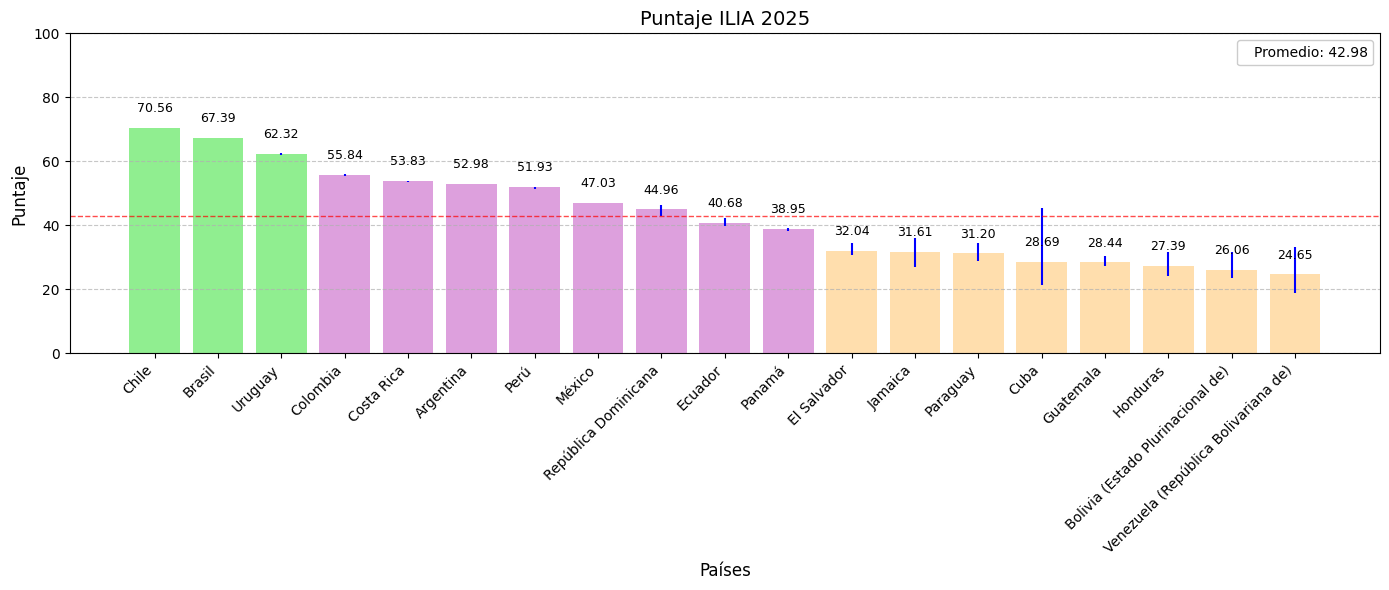

In [ ]:
# Sort the DataFrame by score (descending)
df_sorted = final_df.sort_values("Puntaje ILIA", ascending=False)
average_score = df_sorted['Puntaje ILIA'].mean()

bar_colors = {
    "Chile": "lightgreen",
    "Brasil": "lightgreen",
    "Uruguay": "lightgreen",
    "Colombia": "plum",
    "Costa Rica": "plum",
    "Argentina": "plum",
    "Perú": "plum",
    "México": "plum",
    "República Dominicana": "plum",
    "Ecuador": "plum",
    "Panamá": "plum",
    "El Salvador": "navajowhite",
    "Jamaica": "navajowhite",
    "Paraguay": "navajowhite",
    "Cuba": "navajowhite",
    "Guatemala": "navajowhite",
    "Honduras": "navajowhite",
    "Bolivia (Estado Plurinacional de)": "navajowhite",
    "Venezuela (República Bolivariana de)": "navajowhite"
}

colors = bar_colors.values()

lower_errors, upper_errors = [], []
for country in df_sorted.index:
    low, high = errors_dict.get(country)

    value = df_sorted.loc[country, "Puntaje ILIA"]

    if low == high:
        low_err, high_err = 0, 0
    else:
      low_err = value - low
      high_err = high - value

    lower_errors.append(low_err)
    upper_errors.append(high_err)

error_bars = [lower_errors, upper_errors]

# Create the bar plot
plt.figure(figsize=(14, 6))
bars = plt.bar(df_sorted.index,
               df_sorted['Puntaje ILIA'],
               yerr=error_bars,
               ecolor="blue",
               color=colors,
               label=f'Promedio: {average_score:.2f}')

# Customize the plot
plt.title('Puntaje ILIA 2025', fontsize=14)
plt.ylabel('Puntaje', fontsize=12)
plt.xlabel('Países', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 100)  # This sets the y-axis range from 0 to 100

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height+4,
             f'{height:.2f}',
             ha='center', va='bottom', fontsize=9)

# Add a horizontal line for the average
plt.axhline(y=average_score, color='red', linestyle='--', linewidth=1, alpha=0.7)

# Add legend with average value
plt.legend(loc='upper right', framealpha=1, labelcolor="black", handlelength=0)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ilia_total2025.png")
plt.show()